In [2]:
import json
import os
from PIL import Image
import matplotlib.pyplot as plt

### SQA test

In [3]:
# Config paths (adjust if needed)
sqa_test_folder = '../data/qa/SQA/SQA_test.json'
image_folder = '../data/qa/scannetv2/frames_square'

# Load the dataset
with open(sqa_test_folder, 'r') as f:
    sqa_data = json.load(f)

# Print dataset size
print(f"Total samples: {len(sqa_data)}")

Total samples: 3519


In [4]:
# View one sample
sample = sqa_data[0]
sample

{'answers': ['piano'],
 'object_ids': [],
 'object_names': [],
 'question': 'What instrument in front of me is ebony and ivory?',
 'situation': 'I am standing by the ottoman on my right facing a couple of toolboxes.',
 'question_id': 220602000002,
 'scene_id': 'scene0050_00',
 'position': [0.7110268899979686,
  -0.03219739162793617,
  0,
  0,
  0,
  -0.9995736030415032,
  -0.02919952230128897]}


Scene has 233 images total


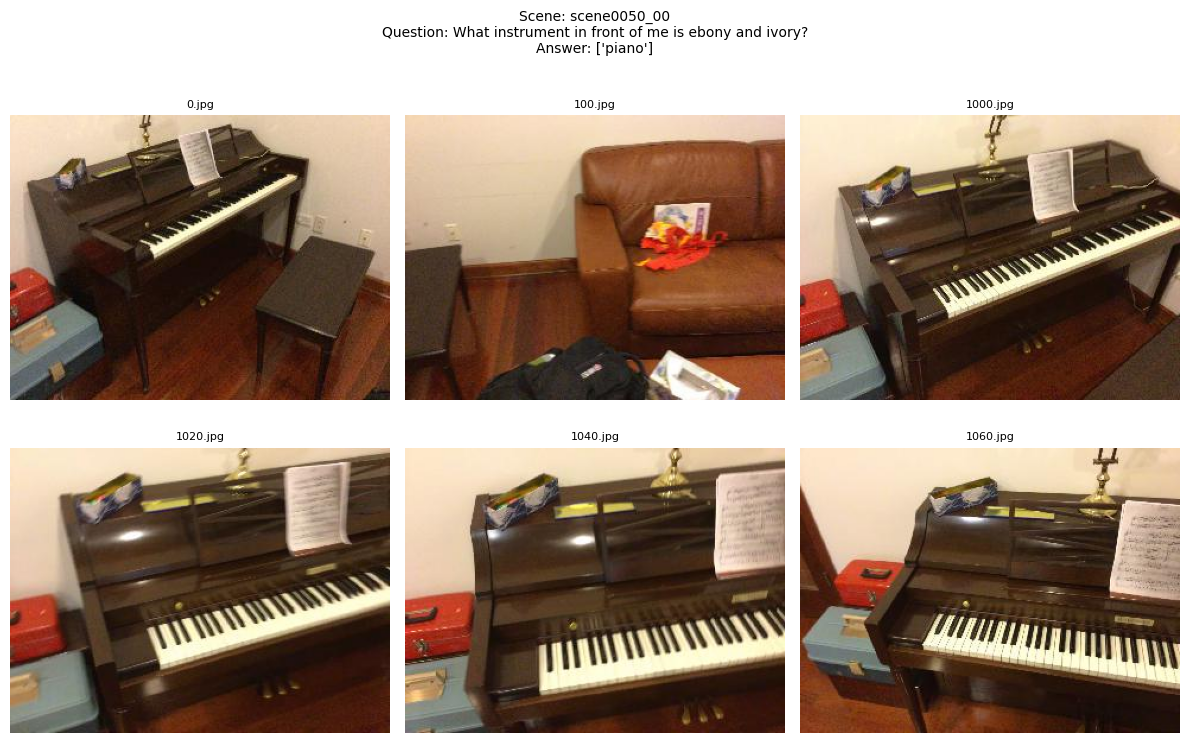

In [5]:
# Show a few images from this scene
scene_id = sample['scene_id']
color_folder = os.path.join(image_folder, scene_id, 'color')
image_files = sorted(os.listdir(color_folder))[:6]  # First 6 images

print(f"\nScene has {len(os.listdir(color_folder))} images total")

# Display images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle(f"Scene: {scene_id}\nQuestion: {sample['question']}\nAnswer: {sample['answers']}", fontsize=10)

for idx, (ax, img_file) in enumerate(zip(axes.flat, image_files)):
    img_path = os.path.join(color_folder, img_file)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_file, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

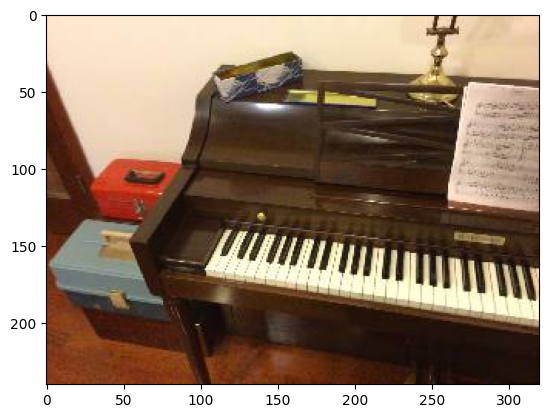

In [6]:
# write  code to plot just the first image
plt.imshow(Image.open(os.path.join(color_folder, image_files[5])))
plt.show()

### Set-of-Mark (SoM) Prompting

[Set-of-Mark](https://arxiv.org/abs/2310.11441) (Yang et al., 2023) is a visual prompting
technique that overlays numbered marks on automatically segmented image regions.
This helps vision-language models reference specific objects/areas by their mark ID.

**Pipeline:** Image → SAM (segment everything) → color-coded masks + numbered labels → SoM image

In [7]:
import numpy as np
import cv2
import colorsys
import torch
from PIL import Image, ImageDraw, ImageFont
from ultralytics.models.sam import SAM2Predictor


DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"


def make_sam2_predictor(model_name="sam2.1_l.pt", device=DEVICE):
    """Create a SAM2Predictor with only valid YOLO overrides."""
    return SAM2Predictor(overrides=dict(
        task="segment",
        mode="predict",
        imgsz=1024,
        model=model_name,
        device=device,
        verbose=False,
        save=False,
    ))


def generate_som_image(
    image_path,
    predictor,
    alpha=0.3,
    min_area_frac=0.0005,
    points_stride=16,
    crop_n_layers=1,
    conf_thres=0.86,
    stability_score_thresh=0.92,
):
    """Generate a Set-of-Mark (SoM) prompted image using SAM2.

    Segments the image with SAM2 in 'segment everything' mode using tuned
    parameters, then overlays colour-coded translucent masks with numbered
    labels at each segment centroid.

    Args:
        image_path: Path to the input image.
        predictor: A SAM2Predictor instance.
        alpha: Mask overlay opacity (0 = invisible, 1 = opaque).
        min_area_frac: Ignore masks smaller than this fraction of total pixels.
        points_stride: Sampling density — lower = denser grid = more segments.
        crop_n_layers: Extra crop layers for multi-scale mask generation.
        conf_thres: Predicted-IoU confidence threshold for mask quality.
        stability_score_thresh: Stability score threshold for mask filtering.

    Returns:
        som_img: np.ndarray (H, W, 3) — the marked image.
        n_marks: int — number of marks drawn.
    """
    img = np.array(Image.open(image_path).convert("RGB"))
    h, w = img.shape[:2]
    min_area = min_area_frac * h * w

    # SAM-specific generate kwargs are passed here (NOT in the constructor),
    # so they flow through __call__ → stream_inference → inference → generate
    # without hitting YOLO config validation.
    results = predictor(
        source=image_path,
        points_stride=points_stride,
        crop_n_layers=crop_n_layers,
        conf_thres=conf_thres,
        stability_score_thresh=stability_score_thresh,
    )

    if not results or results[0].masks is None:
        print("No masks detected.")
        return img, 0

    masks_raw = results[0].masks.data.cpu().numpy()
    scores = results[0].boxes.conf.cpu().numpy() if results[0].boxes is not None else None

    # Resize masks to image dimensions and filter by area
    processed = []
    for i, m in enumerate(masks_raw):
        if m.shape != (h, w):
            m = cv2.resize(m.astype(np.uint8), (w, h),
                           interpolation=cv2.INTER_NEAREST)
        mask_bool = m.astype(bool)
        area = mask_bool.sum()
        if area >= min_area:
            score = float(scores[i]) if scores is not None and i < len(scores) else 1.0
            processed.append((mask_bool, area, score))

    # Sort largest-first so small segments are painted on top
    processed.sort(key=lambda x: x[1], reverse=True)

    n = len(processed)
    if n == 0:
        print("All masks were below the minimum area threshold.")
        return img, 0

    # Distinct colours via golden-ratio hue spacing (avoids adjacent similarity)
    colors = []
    golden_ratio_inv = 0.618033988749895
    hue = 0.0
    for _ in range(n):
        r, g, b = colorsys.hsv_to_rgb(hue % 1.0, 0.75, 0.95)
        colors.append(np.array([int(r * 255), int(g * 255), int(b * 255)],
                               dtype=np.float64))
        hue += golden_ratio_inv

    # --- Paint translucent masks + contour outlines ---
    overlay = img.astype(np.float64)
    contour_layer = np.zeros_like(img)

    for (mask, _area, _score), color in zip(processed, colors):
        overlay[mask] = overlay[mask] * (1 - alpha) + color * alpha
        contours, _ = cv2.findContours(
            mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(contour_layer, contours, -1,
                         color.astype(int).tolist(), 2)

    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    contour_pixels = contour_layer.any(axis=2)
    overlay[contour_pixels] = contour_layer[contour_pixels]

    # --- Draw numbered labels ---
    som_pil = Image.fromarray(overlay)
    draw = ImageDraw.Draw(som_pil)

    font_size = max(12, min(h, w) // 45)
    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", font_size)
    except OSError:
        font = ImageFont.load_default()

    for idx, ((mask, _area, _score), color) in enumerate(zip(processed, colors)):
        ys, xs = np.where(mask)
        if len(xs) == 0:
            continue
        cx, cy = int(xs.mean()), int(ys.mean())

        label = str(idx + 1)
        bbox = draw.textbbox((0, 0), label, font=font)
        tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
        pad = 4

        draw.rounded_rectangle(
            [cx - tw // 2 - pad, cy - th // 2 - pad,
             cx + tw // 2 + pad, cy + th // 2 + pad],
            radius=4, fill=(0, 0, 0, 210))
        draw.text((cx - tw // 2, cy - th // 2), label,
                  fill=(255, 255, 255), font=font)

    return np.array(som_pil), n

In [8]:
# SAM 2.1 Large — best accuracy, fast on V100 GPU
# Downloads sam2.1_l.pt automatically on first run (~430 MB)
print(f"Using device: {DEVICE}")

predictor = make_sam2_predictor("sam2.1_s.pt", device=DEVICE)

Using device: cuda:0


In [9]:
"""
som_image, n_marks = generate_som_image(
    test_image_path,
    predictor,
    points_stride=16,              # dense point grid (default 32)
    crop_n_layers=1,               # multi-scale crops for small objects
    conf_thres=0.86,               # predicted-IoU quality threshold
    stability_score_thresh=0.92,   # mask stability threshold
)
"""

'\nsom_image, n_marks = generate_som_image(\n    test_image_path,\n    predictor,\n    points_stride=16,              # dense point grid (default 32)\n    crop_n_layers=1,               # multi-scale crops for small objects\n    conf_thres=0.86,               # predicted-IoU quality threshold\n    stability_score_thresh=0.92,   # mask stability threshold\n)\n'

Ultralytics 8.4.30 🚀 Python-3.10.19 torch-2.11.0+cu126 CUDA:0 (Tesla V100-SXM2-32GB, 32494MiB)


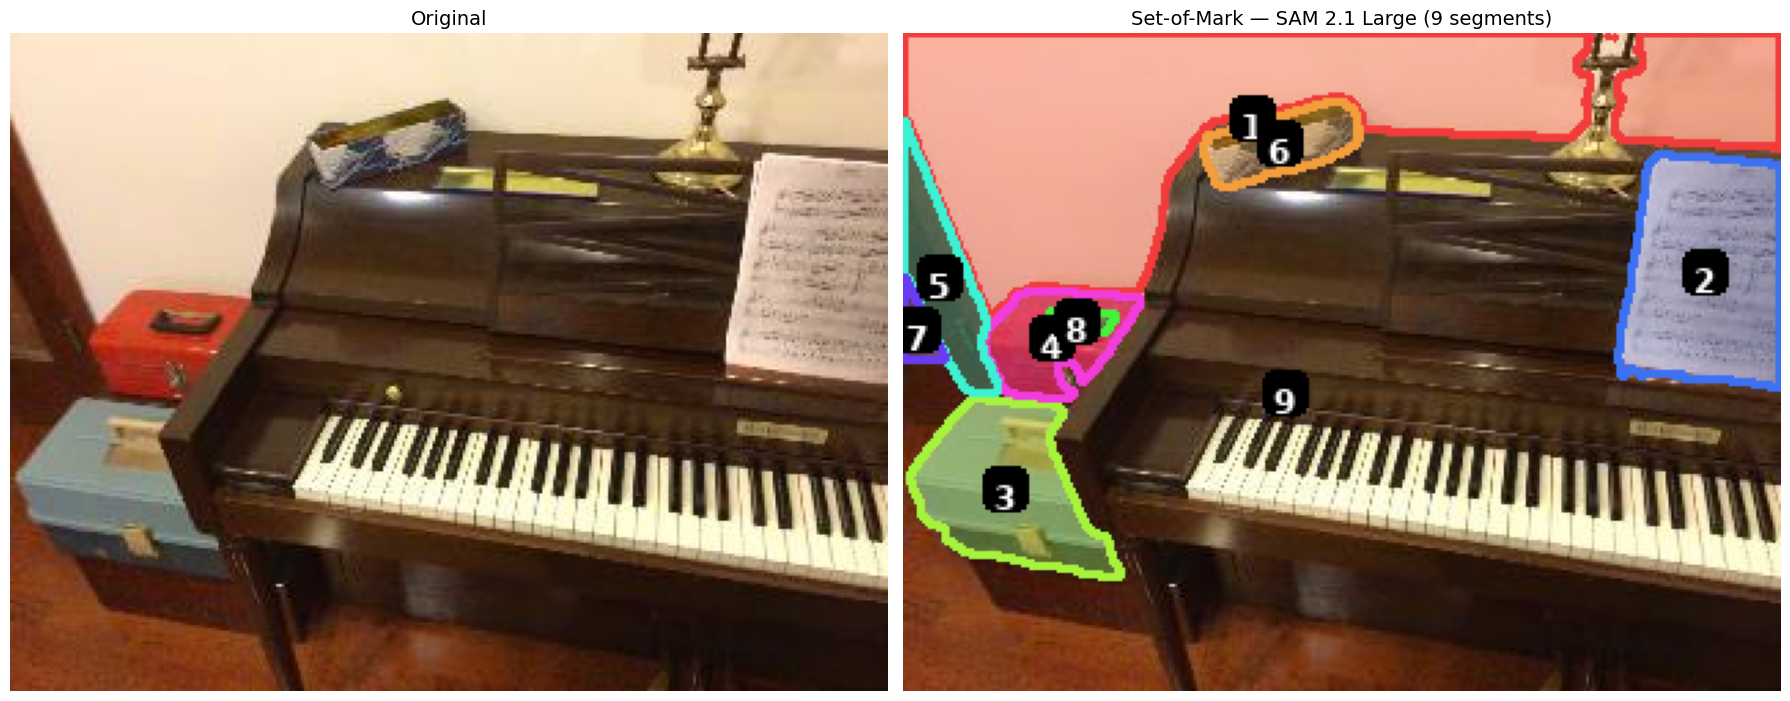

In [10]:
# Use the first image from the scene loaded earlier
test_image_path = os.path.join(color_folder, image_files[5])

som_image, n_marks = generate_som_image(
    test_image_path,
    predictor,
    points_stride=16,              # dense point grid (default 32)
    crop_n_layers=1,               # multi-scale crops for small objects
    conf_thres=0.86,               # predicted-IoU quality threshold
    stability_score_thresh=0.92,   # mask stability threshold
)

# Show original vs SoM side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(Image.open(test_image_path))
axes[0].set_title("Original", fontsize=14)
axes[0].axis("off")

axes[1].imshow(som_image)
axes[1].set_title(f"Set-of-Mark — SAM 2.1 Large ({n_marks} segments)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Multi-View Object 3D Localization Pipeline

**Goal:** Detect objects by name in RGB views, then back-project through depth maps
to recover each object's 3D world coordinate.

**Pipeline:**
1. **Select keyframes** — pick N evenly-spaced views (avoid redundant nearby frames)
2. **Detect + Segment** — YOLO-World (open-vocab detection → names + boxes) → SAM2 (boxes → precise masks)
3. **Back-project** — for each mask, use depth + intrinsics + extrinsic pose to lift masked pixels to 3D world points; take the median as the object centroid
4. **Multi-view fusion** — cluster same-class 3D centroids across views with DBSCAN → one cluster = one physical object instance

In [11]:
import numpy as np
import os, glob, json
from PIL import Image
from sklearn.cluster import DBSCAN
from collections import defaultdict

# ─── Data loaders for ScanNet frames_square ──────────────────────────

def load_intrinsics(scene_dir):
    """Load 4x4 intrinsic matrix and scale to depth resolution (320x240).
    
    ScanNet intrinsic_depth.txt stores intrinsics at 640x480 native resolution.
    The depth images in frames_square are 320x240 → scale fx,fy,cx,cy by 0.5.
    """
    K = np.loadtxt(os.path.join(scene_dir, "intrinsic_depth.txt"))
    # Check if scaling is needed by comparing to actual depth image size
    sample_depth = sorted(glob.glob(os.path.join(scene_dir, "depth", "*.png")))[0]
    dh, dw = np.array(Image.open(sample_depth)).shape[:2]
    # If cx > dw, intrinsics are for a higher resolution → scale down
    if K[0, 2] > dw:
        scale = dw / (K[0, 2] * 2)   # e.g. 320 / (319*2) ≈ 0.5
        K[0, 0] *= scale  # fx
        K[1, 1] *= scale  # fy
        K[0, 2] *= scale  # cx
        K[1, 2] *= scale  # cy
    return K


def load_pose(scene_dir, frame_id):
    """Load 4x4 camera-to-world pose matrix for a frame."""
    pose = np.loadtxt(os.path.join(scene_dir, "pose", f"{frame_id}.txt"))
    if np.any(np.isinf(pose)) or np.any(np.isnan(pose)):
        return None
    return pose


def load_depth(scene_dir, frame_id):
    """Load depth map in meters (ScanNet stores uint16 millimeters)."""
    path = os.path.join(scene_dir, "depth", f"{frame_id}.png")
    depth = np.array(Image.open(path)).astype(np.float32) / 1000.0
    return depth


def get_frame_ids(scene_dir):
    """Get sorted list of all available frame IDs."""
    files = glob.glob(os.path.join(scene_dir, "color", "*.jpg"))
    ids = sorted([int(os.path.splitext(os.path.basename(f))[0]) for f in files])
    return ids


def select_keyframes(frame_ids, n_keyframes=20):
    """Evenly sample n keyframes from all available frames."""
    if len(frame_ids) <= n_keyframes:
        return frame_ids
    indices = np.linspace(0, len(frame_ids) - 1, n_keyframes, dtype=int)
    return [frame_ids[i] for i in indices]


# ─── 2D mask → 3D world coordinates ──────────────────────────────────

def backproject_mask(mask, depth, K, cam2world, max_depth=5.0, subsample=500):
    """Back-project pixels within a binary mask to 3D world coordinates.
    
    Args:
        mask: (H, W) boolean mask
        depth: (H, W) float depth in meters
        K: 4x4 intrinsic matrix
        cam2world: 4x4 extrinsic pose (camera → world)
        max_depth: ignore depth values above this (noisy)
        subsample: max points to use (for speed)
    
    Returns:
        points_world: (N, 3) array of 3D world points, or None if too few valid
    """
    fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]
    
    vs, us = np.where(mask)
    depths = depth[vs, us]

    valid = (depths > 0.01) & (depths < max_depth)
    us, vs, depths = us[valid], vs[valid], depths[valid]

    if len(us) < 10:
        return None

    if len(us) > subsample:
        idx = np.random.choice(len(us), subsample, replace=False)
        us, vs, depths = us[idx], vs[idx], depths[idx]

    # Pixel → camera coordinates
    X_cam = (us - cx) * depths / fx
    Y_cam = (vs - cy) * depths / fy
    Z_cam = depths

    pts_cam = np.stack([X_cam, Y_cam, Z_cam, np.ones_like(Z_cam)], axis=1)  # (N, 4)

    pts_world = (cam2world @ pts_cam.T).T[:, :3]  # (N, 3)
    return pts_world


def mask_to_3d_centroid(mask, depth, K, cam2world):
    """Get the median 3D world coordinate for a mask (robust to outliers)."""
    pts = backproject_mask(mask, depth, K, cam2world)
    if pts is None:
        return None
    return np.median(pts, axis=0)

print("Utilities loaded.")

Utilities loaded.


In [12]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import clip
import cv2
import torch
from ultralytics import YOLOWorld
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize

# ─── CLIP-based scene discovery ──────────────────────────────────────
# Instead of a small fixed vocab, we use CLIP to figure out what's
# actually in the scene by classifying SAM2 segments zero-shot.

CANDIDATE_CLASSES = [
    # furniture
    "chair", "office chair", "armchair", "table", "dining table", "coffee table",
    "sofa", "couch", "loveseat", "desk", "bed", "nightstand", "dresser",
    "counter", "countertop", "stool", "bar stool", "bench", "ottoman", "futon",
    "recliner", "rocking chair",
    # storage
    "shelf", "bookshelf", "cabinet", "drawer", "wardrobe", "closet", "cupboard",
    "filing cabinet", "storage bin", "chest",
    # doors/windows/walls
    "door", "window", "curtain", "blinds", "shutter",
    # lighting
    "lamp", "floor lamp", "table lamp", "ceiling light", "chandelier",
    "light fixture", "sconce",
    # electronics
    "monitor", "computer monitor", "tv", "television", "screen", "keyboard",
    "computer keyboard", "laptop", "printer", "speaker", "projector",
    # kitchen
    "refrigerator", "fridge", "microwave", "oven", "stove", "dishwasher",
    "toaster", "coffee maker",
    # bathroom
    "sink", "toilet", "bathtub", "shower", "shower curtain",
    # wall decor
    "mirror", "picture", "picture frame", "painting", "clock", "poster",
    "whiteboard", "bulletin board", "calendar",
    # textiles
    "pillow", "cushion", "blanket", "towel", "rug", "carpet", "mat",
    "curtain", "tablecloth",
    # containers
    "bottle", "cup", "mug", "bowl", "plate", "glass", "jar", "can",
    "pitcher", "vase",
    # bags/boxes
    "bag", "backpack", "suitcase", "box", "cardboard box", "bin",
    "trash can", "recycling bin", "basket", "crate",
    # objects
    "book", "paper", "notebook", "magazine", "newspaper",
    "phone", "cell phone", "remote", "remote control",
    "pen", "pencil", "scissors", "tape", "stapler",
    # appliances
    "fan", "heater", "radiator", "air conditioner", "humidifier",
    "vacuum cleaner", "iron",
    # plants
    "plant", "potted plant", "flower", "flower pot", "tree",
    # instruments
    "piano", "keyboard instrument", "guitar", "violin", "drum",
    # misc furniture
    "bookcase", "shoe rack", "coat rack", "umbrella stand", "wine rack",
    "tv stand", "entertainment center", "sideboard",
    # misc objects
    "umbrella", "hat", "helmet", "shoe", "boot", "coat", "jacket",
    "toy", "stuffed animal", "ball", "board game",
    "candle", "tissue box", "soap dispenser", "toothbrush holder",
    "fire extinguisher", "smoke detector",
    # structural
    "column", "pillar", "beam", "pipe", "vent", "electrical outlet",
    "light switch", "thermostat", "doorknob",
    "stairs", "staircase", "railing", "banister",
    "wall", "floor", "ceiling",
]

def load_clip_model(device=DEVICE):
    model, preprocess = clip.load("ViT-B/32", device=device)
    return model, preprocess

def discover_scene_classes(
    scene_dir, sam_predictor, clip_model, clip_preprocess,
    candidate_classes=CANDIDATE_CLASSES,
    n_discovery_frames=5,
    clip_threshold=0.20,
    min_area_frac=0.005,
    device=DEVICE,
):
    """Auto-discover which object categories exist in a scene.
    
    Runs SAM2 segment-everything on a few frames, crops each segment,
    and classifies it with CLIP zero-shot. Returns the set of class
    names that appear with confidence above threshold.
    """
    frame_ids = get_frame_ids(scene_dir)
    sample_ids = select_keyframes(frame_ids, n_discovery_frames)
    
    text_tokens = clip.tokenize(candidate_classes).to(device)
    with torch.no_grad():
        text_feats = clip_model.encode_text(text_tokens)
        text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)

    discovered = defaultdict(float)

    for fid in sample_ids:
        color_path = os.path.join(scene_dir, "color", f"{fid}.jpg")
        img_pil = Image.open(color_path).convert("RGB")
        img_np = np.array(img_pil)
        h, w = img_np.shape[:2]
        min_area = min_area_frac * h * w

        results = sam_predictor(
            source=color_path,
            points_stride=32,
            crop_n_layers=0,
            conf_thres=0.88,
            stability_score_thresh=0.92,
        )
        if not results or results[0].masks is None:
            continue

        masks = results[0].masks.data.cpu().numpy()

        for m in masks:
            if m.shape != (h, w):
                m = cv2.resize(m.astype(np.uint8), (w, h),
                               interpolation=cv2.INTER_NEAREST)
            mask_bool = m.astype(bool)
            if mask_bool.sum() < min_area:
                continue

            ys, xs = np.where(mask_bool)
            y1, y2 = ys.min(), ys.max()
            x1, x2 = xs.min(), xs.max()
            pad = 5
            y1, x1 = max(0, y1 - pad), max(0, x1 - pad)
            y2, x2 = min(h, y2 + pad), min(w, x2 + pad)
            crop = img_pil.crop((x1, y1, x2, y2))

            crop_tensor = clip_preprocess(crop).unsqueeze(0).to(device)
            with torch.no_grad():
                img_feat = clip_model.encode_image(crop_tensor)
                img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
                sims = (img_feat @ text_feats.T).squeeze(0)
                probs = sims.softmax(dim=0).cpu().numpy()

            best_idx = probs.argmax()
            best_prob = probs[best_idx]
            if best_prob >= clip_threshold:
                name = candidate_classes[best_idx]
                discovered[name] = max(discovered[name], float(best_prob))

    found = sorted(discovered.keys(), key=lambda k: discovered[k], reverse=True)
    print(f"Discovery: found {len(found)} classes across {len(sample_ids)} frames")
    for name in found:
        print(f"  {name:30s}  (max CLIP score: {discovered[name]:.3f})")
    return found


# ─── Models ──────────────────────────────────────────────────────────

clip_model, clip_preprocess = load_clip_model()
yolo_world = YOLOWorld("yolov8x-worldv2.pt")
print(f"CLIP + YOLO-World loaded on {DEVICE}")


# ─── Per-frame: detect + segment + back-project ──────────────────────

def detect_and_locate_3d(
    scene_dir,
    frame_id,
    yolo_model,
    sam_predictor,
    K,
    det_conf=0.10,
    min_mask_area=150,
):
    """Detect → SAM2 segment → depth back-project for one frame."""
    color_path = os.path.join(scene_dir, "color", f"{frame_id}.jpg")
    cam2world = load_pose(scene_dir, frame_id)
    if cam2world is None:
        return []

    depth = load_depth(scene_dir, frame_id)

    det_results = yolo_model(color_path, conf=det_conf, verbose=False)
    boxes = det_results[0].boxes
    if boxes is None or len(boxes) == 0:
        return []

    bboxes_np = boxes.xyxy.cpu().numpy()
    class_ids = boxes.cls.cpu().numpy().astype(int)
    confs = boxes.conf.cpu().numpy()
    names = [yolo_model.names[c] for c in class_ids]

    sam_results = sam_predictor(source=color_path, bboxes=bboxes_np)
    if not sam_results or sam_results[0].masks is None:
        return []

    masks_raw = sam_results[0].masks.data.cpu().numpy()
    h, w = depth.shape

    detections = []
    for i, (name, conf) in enumerate(zip(names, confs)):
        if i >= len(masks_raw):
            break
        mask = masks_raw[i]
        if mask.shape != (h, w):
            mask = cv2.resize(mask.astype(np.uint8), (w, h),
                              interpolation=cv2.INTER_NEAREST)
        mask = mask.astype(bool)
        if mask.sum() < min_mask_area:
            continue

        centroid = mask_to_3d_centroid(mask, depth, K, cam2world)
        if centroid is None:
            continue

        detections.append({
            "name": name,
            "confidence": float(conf),
            "centroid_3d": centroid,
            "bbox": bboxes_np[i].tolist(),
            "frame_id": frame_id,
        })

    return detections

print("Detection pipeline ready.")

CLIP + YOLO-World loaded on cuda:0
Detection pipeline ready.


In [13]:
# ─── Multi-view fusion: cluster detections into object instances ──────

def fuse_multiview_detections(all_detections, eps=0.3, min_samples=2):
    """Cluster per-frame 3D detections into unique object instances.
    
    Groups detections by class name, then uses DBSCAN to merge
    nearby centroids from different views into a single instance.
    
    Args:
        all_detections: flat list of detection dicts from detect_and_locate_3d
        eps: DBSCAN radius in meters (0.3m works well for indoor objects)
        min_samples: minimum views to confirm an object exists
    
    Returns:
        objects: list of dicts [{name, position_3d, n_views, avg_confidence}, ...]
    """
    by_class = defaultdict(list)
    for det in all_detections:
        by_class[det["name"]].append(det)

    objects = []
    for name, dets in by_class.items():
        centroids = np.array([d["centroid_3d"] for d in dets])
        confs = np.array([d["confidence"] for d in dets])

        if len(centroids) == 1:
            if confs[0] >= 0.25:
                objects.append({
                    "name": name,
                    "position_3d": centroids[0],
                    "n_views": 1,
                    "avg_confidence": float(confs[0]),
                })
            continue

        clustering = DBSCAN(eps=eps, min_samples=min(min_samples, len(centroids))).fit(centroids)
        labels = clustering.labels_

        for label in set(labels):
            if label == -1:
                continue
            member_mask = labels == label
            cluster_pts = centroids[member_mask]
            cluster_confs = confs[member_mask]
            objects.append({
                "name": name,
                "position_3d": cluster_pts.mean(axis=0),
                "n_views": int(member_mask.sum()),
                "avg_confidence": float(cluster_confs.mean()),
            })

    objects.sort(key=lambda o: (-o["n_views"], -o["avg_confidence"]))
    return objects


def run_full_pipeline(
    scene_dir, yolo_model, sam_predictor, clip_mdl, clip_prep,
    n_keyframes=25, n_discovery_frames=5,
):
    """Two-phase pipeline: discover scene vocab → detect → fuse.
    
    Phase 1: CLIP classifies SAM2 segments on a few frames to auto-discover
             which object categories actually exist in this scene.
    Phase 2: YOLO-World runs with the discovered vocabulary on all keyframes,
             SAM2 refines masks, depth back-projects to 3D.
    """
    K = load_intrinsics(scene_dir)
    frame_ids = get_frame_ids(scene_dir)

    # Phase 1: discover what's in the scene
    print("Phase 1: Discovering scene objects with CLIP + SAM2...")
    scene_classes = discover_scene_classes(
        scene_dir, sam_predictor, clip_mdl, clip_prep,
        n_discovery_frames=n_discovery_frames,
    )
    if not scene_classes:
        print("WARNING: no classes discovered, falling back to full candidate list")
        scene_classes = CANDIDATE_CLASSES

    yolo_model.set_classes(scene_classes)
    print(f"\nYOLO-World vocab set to {len(scene_classes)} discovered classes")

    # Phase 2: targeted detection on more keyframes
    keyframes = select_keyframes(frame_ids, n_keyframes)
    print(f"\nPhase 2: Detecting in {len(keyframes)} keyframes "
          f"(from {len(frame_ids)} total)...")

    all_detections = []
    for i, fid in enumerate(keyframes):
        dets = detect_and_locate_3d(scene_dir, fid, yolo_model, sam_predictor, K)
        all_detections.extend(dets)
        if (i + 1) % 5 == 0:
            print(f"  [{i+1}/{len(keyframes)}] {len(all_detections)} detections so far")

    print(f"\nTotal raw detections: {len(all_detections)}")
    objects = fuse_multiview_detections(all_detections)
    print(f"Fused into {len(objects)} unique object instances")
    return objects, all_detections

print("Fusion pipeline ready.")

Fusion pipeline ready.


In [14]:
# ─── Run on a scene ──────────────────────────────────────────────────

scene_dir = os.path.join(image_folder, scene_id)
print(f"Scene: {scene_id}  →  {scene_dir}")

objects_3d, raw_detections = run_full_pipeline(
    scene_dir, yolo_world, predictor, clip_model, clip_preprocess,
    n_keyframes=25, n_discovery_frames=5,
)

# Pretty-print results
print(f"\n{'='*60}")
print(f"  3D Object Map for {scene_id}")
print(f"{'='*60}")
for i, obj in enumerate(objects_3d):
    pos = obj["position_3d"]
    print(f"  {i+1:2d}. {obj['name']:20s}  "
          f"xyz=({pos[0]:+6.2f}, {pos[1]:+6.2f}, {pos[2]:+6.2f})  "
          f"views={obj['n_views']}  conf={obj['avg_confidence']:.2f}")

Scene: scene0050_00  →  ../data/qa/scannetv2/frames_square/scene0050_00
Phase 1: Discovering scene objects with CLIP + SAM2...


Discovery: found 0 classes across 5 frames

YOLO-World vocab set to 178 discovered classes

Phase 2: Detecting in 25 keyframes (from 233 total)...
  [5/25] 80 detections so far
  [10/25] 161 detections so far
  [15/25] 233 detections so far
  [20/25] 284 detections so far
  [25/25] 371 detections so far

Total raw detections: 371
Fused into 67 unique object instances

  3D Object Map for scene0050_00
   1. keyboard instrument   xyz=( +6.17,  +1.56,  +1.09)  views=10  conf=0.28
   2. storage bin           xyz=( +5.50,  +2.42,  +0.43)  views=6  conf=0.35
   3. laptop                xyz=( +2.91,  +3.02,  +0.99)  views=5  conf=0.55
   4. keyboard              xyz=( +2.93,  +3.00,  +0.99)  views=5  conf=0.47
   5. pillow                xyz=( +3.04,  +0.90,  +0.90)  views=4  conf=0.67
   6. piano                 xyz=( +6.26,  +1.54,  +1.05)  views=4  conf=0.54
   7. storage bin           xyz=( +6.42,  +2.19,  +0.66)  views=4  conf=0.35
   8. suitcase              xyz=( +3.97,  +2.18,  +0.75)

/tmp/ipykernel_60981/148387119.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_names))


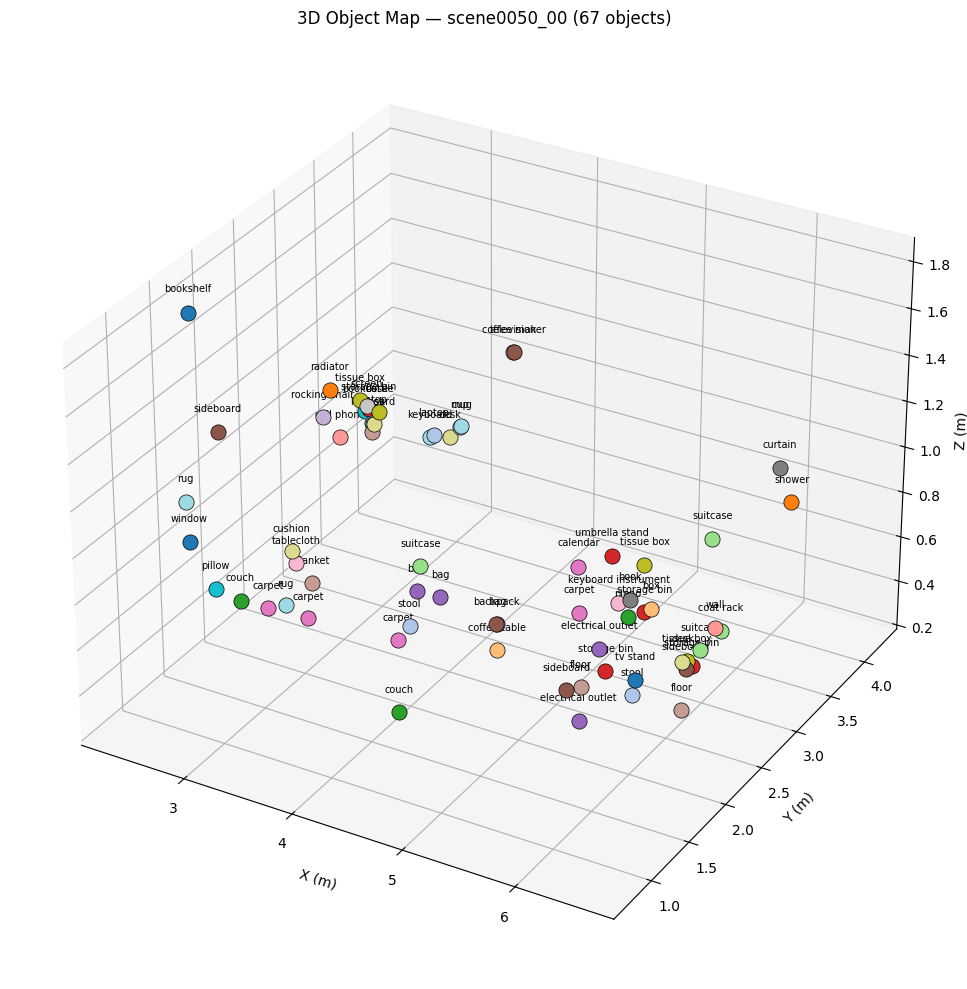


Name                       X       Y       Z Views  Conf
-------------------------------------------------------
keyboard instrument    +6.17   +1.56   +1.09    10  0.28
storage bin            +5.50   +2.42   +0.43     6  0.35
laptop                 +2.91   +3.02   +0.99     5  0.55
keyboard               +2.93   +3.00   +0.99     5  0.47
pillow                 +3.04   +0.90   +0.90     4  0.67
piano                  +6.26   +1.54   +1.05     4  0.54
storage bin            +6.42   +2.19   +0.66     4  0.35
suitcase               +3.97   +2.18   +0.75     4  0.27
box                    +6.26   +1.87   +0.98     4  0.24
bottle                 +3.05   +2.92   +1.09     3  0.65
bag                    +4.33   +1.93   +0.74     3  0.44
electrical outlet      +6.28   +0.90   +0.81     3  0.38
desk                   +3.34   +3.45   +0.87     3  0.37
screen                 +2.89   +2.99   +1.07     3  0.31
storage bin            +2.79   +3.14   +1.01     3  0.30
carpet                 +5.88   

In [15]:
# ─── 3D scatter plot of detected objects ─────────────────────────────

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

unique_names = list({o["name"] for o in objects_3d})
cmap = plt.cm.get_cmap("tab20", len(unique_names))
name_to_color = {n: cmap(i) for i, n in enumerate(unique_names)}

for obj in objects_3d:
    pos = obj["position_3d"]
    color = name_to_color[obj["name"]]
    ax.scatter(*pos, c=[color], s=120, edgecolors='k', linewidths=0.5, zorder=5)
    ax.text(pos[0], pos[1], pos[2] + 0.08, obj["name"],
            fontsize=7, ha='center', va='bottom')

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title(f"3D Object Map — {scene_id} ({len(objects_3d)} objects)")
plt.tight_layout()
plt.show()


# ─── Table view ──────────────────────────────────────────────────────
print(f"\n{'Name':20s} {'X':>7s} {'Y':>7s} {'Z':>7s} {'Views':>5s} {'Conf':>5s}")
print("-" * 55)
for obj in objects_3d:
    p = obj["position_3d"]
    print(f"{obj['name']:20s} {p[0]:+7.2f} {p[1]:+7.2f} {p[2]:+7.2f} "
          f"{obj['n_views']:5d} {obj['avg_confidence']:5.2f}")